# Neural CD-projection update following stimulation

**Goal.** Same question as `latent_update_following_stimulation.ipynb`, but the per-trial
signal is a **neural population state** instead of a behavioral-model latent: we project each
trial's activity onto a **coding direction (CD)** and track how that projection is *updated*
from trial to trial, and whether **stimulation** changes that update.

**Pipeline.**
1. Fit a CD on **unstimulated** trials (`response`: engaged vs no-response, or `reward`:
   rewarded vs unrewarded) using `stim_axis_projection.build_axis`.
2. For every trial, read out a **single scalar** = the CD projection averaged over `READOUT_WINDOW`.
   This scalar is the neural analog of `sumQ`.
3. Align that per-trial scalar to a **trigger trial**, baseline-subtract at `BASELINE_LAG`, and
   group triggers by outcome (`reward`/`no_reward`) x condition (`stim`/`control`).

**Alignment note.** As in the latent notebook, "lag" is counted in **responded (valid) trials**
so the two notebooks are directly comparable. Only the trigger's own outcome is constrained;
`REQUIRE_CLEAN_WINDOW` keeps stim/control windows free of *other* laser trials.


In [32]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

print(f"env ready; modules from {MODULE_PATH}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env ready; modules from /root/capsule/src/aind_dft_ephys_analysis


In [33]:
# =============================================================================
# 2. CONFIG
# =============================================================================
import re

# --- Session ---------------------------------------------------------------
session_date = "863973_2026-08-25_14-18-29"
ephys_session = None   # None -> auto-discover from the PSTH Zarr
PSTH_DIR = Path("/root/capsule/scratch/psth_results")

# --- Unit selection (same combinable filters as the CD notebook) -----------
USE_TAGGED = False
PROBES = ["ProbeA-1", "ProbeA-2", "ProbeA-3", "ProbeA-4"]   # None/[] -> all probes
metrics_csv_path = Path(f"/root/capsule/scratch/opto_tagging/metrics_{session_date}.csv")
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.05)
SELECT_PULSE_INDEX = -1

# --- Coding direction ------------------------------------------------------
CD_AXIS = "response"      # "response" (engaged vs no-response) or "reward" (reward vs no-reward)
# CD orientation: "positive" -> disengaged/no-reward pole is +;
#                 "negative" -> engaged/reward pole is +.
CD_SIGN = "positive"
ALIGN_TO = "go_cue"
FIT_WINDOW = (0.0, 0.5)   # window used to FIT the CD axis
PROJ_WINDOW = (-4.0, 6.0) # time window for the per-trial projection TRACE
# Window over which the per-trial neural scalar is read out from the projection
# trace (this is the neural analog of the latent value). Can differ from FIT_WINDOW
# (e.g. set to the stimulation period or the post-outcome epoch).
READOUT_WINDOW = (-1.0, 0.0)

# --- Event-aligned trial window --------------------------------------------
LAGS = [-2, -1, 0, 1, 2, 3, 4]
BASELINE_LAG = -1
REQUIRE_CLEAN_WINDOW = True

_tag_part = "tagged" if USE_TAGGED else "allqc"
_probe_part = "all_probes" if not PROBES else "probe_" + "_".join(
    re.sub(r"[^0-9A-Za-z._-]", "", str(p)) for p in PROBES)
OUTDIR = Path(f"/root/capsule/scratch/cd_projection_update/{session_date}/{_tag_part}__{_probe_part}")
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"session   : {session_date}")
print(f"CD axis   : {CD_AXIS} (sign={CD_SIGN})")
print(f"fit window: {FIT_WINDOW} | readout window: {READOUT_WINDOW}")
print(f"lags      : {LAGS} (baseline at {BASELINE_LAG})")
print(f"output dir: {OUTDIR}")


session   : 863973_2026-08-25_14-18-29
CD axis   : response (sign=positive)
fit window: (0.0, 0.5) | readout window: (-1.0, 0.0)
lags      : [-2, -1, 0, 1, 2, 3, 4] (baseline at -1)
output dir: /root/capsule/scratch/cd_projection_update/863973_2026-08-25_14-18-29/allqc__probe_ProbeA-1_ProbeA-2_ProbeA-3_ProbeA-4


## 3. Load PSTH + NWB, fit CD, build per-trial projection

Load the PSTH/NWB, select units, fit the CD on **unstimulated** trials, then read out a single
neural scalar per trial (the CD projection averaged over `READOUT_WINDOW`). Build the same
valid-trial arrays as the latent notebook: `y` (neural projection), `reward`, `stim`.


In [34]:
# =============================================================================
# 3. LOAD, FIT CD, BUILD PER-TRIAL NEURAL PROJECTION
# =============================================================================
from nwb_utils import NWBUtils
from create_psth import load_zarr
from stim_axis_projection import select_units, build_axis

# --- discover + load PSTH / NWB ---
if ephys_session is None:
    cands = sorted(PSTH_DIR.glob(f"ecephys_{session_date}_sorted*_0.2s.zarr"))
    if not cands:
        raise FileNotFoundError(
            f"No PSTH Zarr matching ecephys_{session_date}_sorted*_0.2s.zarr in {PSTH_DIR}")
    ephys_session = cands[0].name[:-len("_0.2s.zarr")]
print(f"ephys_session: {ephys_session}")

psth = load_zarr(str(PSTH_DIR / f"{ephys_session}_0.2s.zarr"))
nwb, _ = NWBUtils.combine_nwb(session_name=ephys_session)

# --- laser / reward / response over valid (responded) trials ---
responses = np.asarray(nwb.trials["animal_response"][:])
rewardedL = np.asarray(nwb.trials["rewarded_historyL"][:]).astype(bool)
rewardedR = np.asarray(nwb.trials["rewarded_historyR"][:]).astype(bool)
laser_on  = np.asarray(nwb.trials["laser_on_trial"][:]).astype(int)

valid_mask = responses != 2
abs_idx    = np.where(valid_mask)[0]              # absolute trial id of each valid trial
reward     = (rewardedL | rewardedR).astype(int)[valid_mask]
stim       = laser_on[valid_mask]
n_valid    = int(valid_mask.sum())
opto_trial_ids = np.where(laser_on == 1)[0].astype(np.int64)

# --- unit selection + CD fit (on non-laser trials) ---
unit_ids = select_units(nwb, psth, use_tagged=USE_TAGGED, probes=PROBES,
                        metrics_csv_path=metrics_csv_path, target_cond=target_cond,
                        pulse_index=SELECT_PULSE_INDEX)
if len(unit_ids) < 3:
    raise ValueError(f"Only {len(unit_ids)} units after selection; need >= 3 for a CD.")

res = build_axis(psth, nwb, unit_ids, CD_AXIS, align=ALIGN_TO, fit_window=FIT_WINDOW,
                 proj_window=PROJ_WINDOW, exclude_trial_ids=opto_trial_ids, cd_sign=CD_SIGN)

# --- per-trial neural scalar = CD projection averaged over READOUT_WINDOW ---
def projection_series(axis_res, window):
    time = np.asarray(axis_res.time, dtype=float)
    lo, hi = window
    m = (time >= lo) & (time < hi)
    if m.any():
        sel = np.where(m)[0]
    else:
        sel = np.array([int(np.argmin(np.abs(time - 0.5 * (lo + hi))))])
    out = np.full(n_valid, np.nan)
    for i, tid in enumerate(abs_idx):
        tr = axis_res.trace_by_id.get(int(tid))
        if tr is not None:
            out[i] = float(np.nanmean(np.asarray(tr, dtype=float)[sel]))
    return out

y = projection_series(res, READOUT_WINDOW)

pos_label = res.axis["label_a"]   # the positive pole of the CD
n_missing = int(np.isnan(y).sum())
print(f"units in CD        : {len(unit_ids)}")
print(f"CD = ({res.axis['label_a']}) - ({res.axis['label_b']}) | d'={res.dprime:.2f}, AUC={res.auc:.2f}")
print(f"valid (responded)  : {n_valid}  (projection missing on {n_missing})")
print(f"  rewarded         : {int(reward.sum())}")
print(f"  stim (laser)     : {int(stim.sum())}  (rewarded={int(((stim==1)&(reward==1)).sum())}, no-reward={int(((stim==1)&(reward==0)).sum())})")
print(f"+ pole of y        : {pos_label}")


ephys_session: ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54
Found ephys NWB: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 2204
units in CD        : 579
CD = (disengaged (no-response)) - (engaged (response)) | d'=2.06, AUC=0.59
valid (responded)  : 420  (projection missing on 0)
  rewarded         : 227
  stim (laser)     : 57  (rewarded=37, no-reward=20)
+ pole of y        : disengaged (no-response)


## 4. What does an "update" look like?

One-step change of the neural projection, `d[i] = y[i] - y[i-1]`, for reward vs no-reward
triggers (non-stim only). This shows whether the neural CD state naturally shifts with the
trial outcome before considering stimulation.


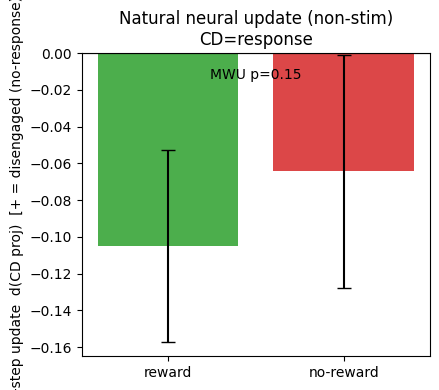

reward   : d(CD proj) = -0.1049 +/- 0.0522  (n=189)
no-reward: d(CD proj) = -0.0644 +/- 0.0633  (n=173)


In [35]:
# =============================================================================
# 4. WHAT DOES A NEURAL "UPDATE" LOOK LIKE?  (control/non-stim trials only)
# =============================================================================
d = np.full(n_valid, np.nan)
d[1:] = y[1:] - y[:-1]

ctrl = stim == 0
upd_rew   = d[ctrl & (reward == 1)]
upd_norew = d[ctrl & (reward == 0)]
upd_rew   = upd_rew[~np.isnan(upd_rew)]
upd_norew = upd_norew[~np.isnan(upd_norew)]

means = [np.mean(upd_rew), np.mean(upd_norew)]
sems  = [np.std(upd_rew, ddof=1) / np.sqrt(len(upd_rew)),
         np.std(upd_norew, ddof=1) / np.sqrt(len(upd_norew))]

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar([0, 1], means, yerr=sems, color=["#2ca02c", "#d62728"], alpha=0.85, capsize=5)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["reward", "no-reward"])
ax.set_ylabel(f"one-step update  d(CD proj)  [+ = {pos_label}]")
ax.set_title(f"Natural neural update (non-stim)\nCD={CD_AXIS}")
u, p = mannwhitneyu(upd_rew, upd_norew, alternative="two-sided")
ax.text(0.5, 0.95, f"MWU p={p:.2g}", transform=ax.transAxes, ha="center", va="top")
plt.tight_layout()
fig.savefig(OUTDIR / f"update_reward_vs_noreward_{CD_AXIS}.png", dpi=150)
plt.show()
print(f"reward   : d(CD proj) = {means[0]:+.4f} +/- {sems[0]:.4f}  (n={len(upd_rew)})")
print(f"no-reward: d(CD proj) = {means[1]:+.4f} +/- {sems[1]:.4f}  (n={len(upd_norew)})")


## 5. Event-aligned neural trajectories

For every trigger, extract the neural projection at each lag, baseline-subtracted at
`BASELINE_LAG`, and group by outcome x condition. Same trigger logic as the latent notebook.


In [36]:
# =============================================================================
# 5. EVENT-ALIGNED NEURAL TRAJECTORIES (reward/no-reward x stim/control)
# =============================================================================
LAGS = list(LAGS)
_nonzero = [l for l in LAGS if l != 0]

def _window_clean(i):
    for l in _nonzero:
        j = i + l
        if 0 <= j < n_valid and stim[j] == 1:
            return False
    return True

def build_trigger_rows(series):
    rows = []
    b0 = BASELINE_LAG
    for i in range(n_valid):
        b = i + b0
        if b < 0 or b >= n_valid or np.isnan(series[b]):
            continue
        if REQUIRE_CLEAN_WINDOW and not _window_clean(i):
            continue
        traj = np.full(len(LAGS), np.nan)
        for k, l in enumerate(LAGS):
            j = i + l
            if 0 <= j < n_valid:
                traj[k] = series[j] - series[b]
        rows.append(dict(
            i=i,
            outcome="reward" if reward[i] == 1 else "no_reward",
            cond="stim" if stim[i] == 1 else "control",
            traj=traj,
        ))
    return rows

GROUP_KEYS = [("reward", "stim"), ("reward", "control"),
              ("no_reward", "stim"), ("no_reward", "control")]

def group_trajectories(series):
    rows = build_trigger_rows(series)
    g = {}
    for key in GROUP_KEYS:
        sel = [r["traj"] for r in rows if (r["outcome"], r["cond"]) == key]
        g[key] = np.vstack(sel) if sel else np.empty((0, len(LAGS)))
    return g

groups = group_trajectories(y)
for key, M in groups.items():
    print(f"{key[0]:9s} / {key[1]:7s}: {M.shape[0]} triggers")


reward    / stim   : 37 triggers
reward    / control: 35 triggers
no_reward / stim   : 19 triggers
no_reward / control: 38 triggers


## 6. Trajectory figure: stim vs control, split by outcome

Mean +/- SEM neural CD-projection trajectory following reward (left) and no-reward (right)
triggers, stim (blue) vs control (grey). Stars mark lags with a stim-vs-control
Mann-Whitney difference (p < 0.05).


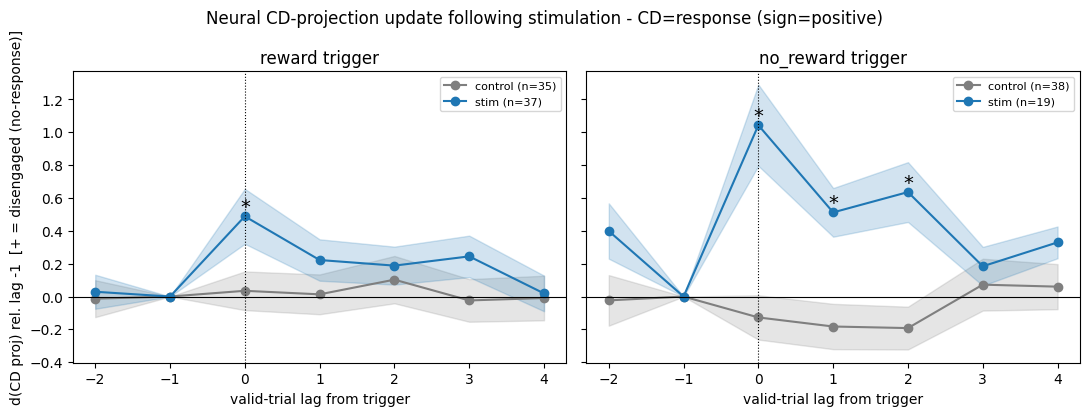

In [37]:
# =============================================================================
# 6. TRAJECTORY FIGURE: stim vs control, split by outcome
# =============================================================================
def _mean_sem(M):
    if M.shape[0] == 0:
        return np.full(M.shape[1], np.nan), np.full(M.shape[1], np.nan)
    n = np.sum(~np.isnan(M), axis=0)
    mean = np.nanmean(M, axis=0)
    sd = np.nanstd(M, axis=0, ddof=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem = sd / np.sqrt(np.maximum(n, 1))
    return mean, sem

lags_arr = np.array(LAGS)
colors = {"stim": "#1f77b4", "control": "#7f7f7f"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, outcome in zip(axes, ["reward", "no_reward"]):
    for cond in ["control", "stim"]:
        M = groups[(outcome, cond)]
        mean, sem = _mean_sem(M)
        ax.plot(lags_arr, mean, "-o", color=colors[cond], label=f"{cond} (n={M.shape[0]})")
        ax.fill_between(lags_arr, mean - sem, mean + sem, color=colors[cond], alpha=0.2)
    Ms, Mc = groups[(outcome, "stim")], groups[(outcome, "control")]
    for k, l in enumerate(LAGS):
        a = Ms[:, k]; b = Mc[:, k]
        a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
        if len(a) >= 3 and len(b) >= 3:
            _, p = mannwhitneyu(a, b, alternative="two-sided")
            if p < 0.05:
                ytxt = np.nanmax([np.nanmean(Ms[:, k]), np.nanmean(Mc[:, k])])
                ax.text(l, ytxt, "*", ha="center", va="bottom", fontsize=14)
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("valid-trial lag from trigger")
    ax.set_title(f"{outcome} trigger")
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"d(CD proj) rel. lag {BASELINE_LAG}  [+ = {pos_label}]")
fig.suptitle(f"Neural CD-projection update following stimulation - CD={CD_AXIS} (sign={CD_SIGN})")
plt.tight_layout()
fig.savefig(OUTDIR / f"trajectory_{CD_AXIS}.png", dpi=150)
plt.show()


## 7. Immediate (one-step) neural update: stim vs control

The update at the trigger = `traj(lag 0) - traj(baseline)` = `y[trigger] - y[trigger-1]`,
compared stim vs control within each outcome (Mann-Whitney U).


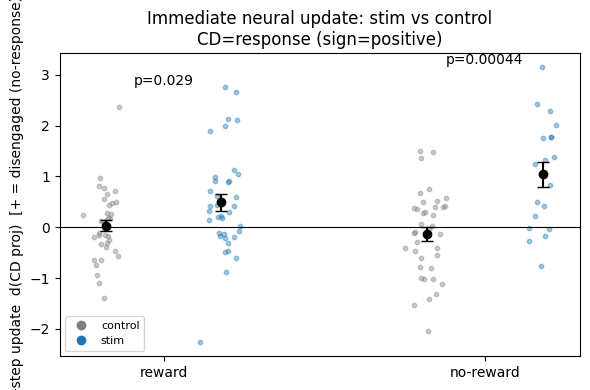

,outcome,control_mean,n_control,stim_mean,n_stim,diff,mannwhitney_p
0,reward,0.034960,35,0.488429,37,0.453469,0.028836
1,no_reward,-0.127198,38,1.043488,19,1.170686,0.000444


In [38]:
# =============================================================================
# 7. ONE-STEP NEURAL UPDATE: stim vs control within each outcome
# =============================================================================
k0 = LAGS.index(0)
upd = {key: M[:, k0] for key, M in groups.items()}
upd = {key: v[~np.isnan(v)] for key, v in upd.items()}

positions = {"reward": 0, "no_reward": 1}
offsets = {"control": -0.18, "stim": 0.18}
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(6, 4))
summary_rows = []
for outcome in ["reward", "no_reward"]:
    for cond in ["control", "stim"]:
        v = upd[(outcome, cond)]
        x = positions[outcome] + offsets[cond]
        ax.scatter(x + rng.normal(0, 0.03, len(v)), v, s=10, color=colors[cond], alpha=0.4)
        if len(v):
            m = np.mean(v); s = np.std(v, ddof=1) / np.sqrt(len(v))
            ax.errorbar(x, m, yerr=s, fmt="o", color="k", capsize=4, zorder=5)
    a = upd[(outcome, "stim")]; b = upd[(outcome, "control")]
    p = mannwhitneyu(a, b, alternative="two-sided")[1] if (len(a) >= 3 and len(b) >= 3) else np.nan
    summary_rows.append(dict(
        outcome=outcome,
        control_mean=np.mean(b) if len(b) else np.nan, n_control=len(b),
        stim_mean=np.mean(a) if len(a) else np.nan, n_stim=len(a),
        diff=(np.mean(a) - np.mean(b)) if (len(a) and len(b)) else np.nan,
        mannwhitney_p=p,
    ))
    yt = ax.get_ylim()[1]
    ax.text(positions[outcome], yt, f"p={p:.2g}" if np.isfinite(p) else "n/a",
            ha="center", va="top")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["reward", "no-reward"])
ax.set_ylabel(f"one-step update  d(CD proj)  [+ = {pos_label}]")
ax.set_title(f"Immediate neural update: stim vs control\nCD={CD_AXIS} (sign={CD_SIGN})")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0], [0], marker="o", ls="", color=colors[c], label=c)
                   for c in ["control", "stim"]], fontsize=8)
plt.tight_layout()
fig.savefig(OUTDIR / f"onestep_update_stim_vs_control_{CD_AXIS}.png", dpi=150)
plt.show()

upd_df = pd.DataFrame(summary_rows)
upd_df.to_csv(OUTDIR / f"onestep_update_stim_vs_control_{CD_AXIS}.csv", index=False)
display(upd_df)


## 8. Per-lag summary table

Cumulative neural change `y[lag] - y[baseline]` per outcome and lag, with the stim-vs-control
Mann-Whitney p-value. Saved to CSV.


In [39]:
# =============================================================================
# 8. PER-LAG SUMMARY TABLE (cumulative neural change + stim-vs-control test)
# =============================================================================
rows_out = []
for outcome in ["reward", "no_reward"]:
    Ms, Mc = groups[(outcome, "stim")], groups[(outcome, "control")]
    for k, l in enumerate(LAGS):
        a = Ms[:, k]; b = Mc[:, k]
        a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
        p = mannwhitneyu(a, b, alternative="two-sided")[1] if (len(a) >= 3 and len(b) >= 3) else np.nan
        rows_out.append(dict(
            outcome=outcome, lag=l,
            control_mean=np.mean(b) if len(b) else np.nan, n_control=len(b),
            stim_mean=np.mean(a) if len(a) else np.nan, n_stim=len(a),
            diff=(np.mean(a) - np.mean(b)) if (len(a) and len(b)) else np.nan,
            mannwhitney_p=p,
        ))
lag_df = pd.DataFrame(rows_out)
lag_path = OUTDIR / f"perlag_summary_{CD_AXIS}.csv"
lag_df.to_csv(lag_path, index=False)
print(f"saved -> {lag_path}")
display(lag_df)


saved -> /root/capsule/scratch/cd_projection_update/863973_2026-08-25_14-18-29/allqc__probe_ProbeA-1_ProbeA-2_ProbeA-3_ProbeA-4/perlag_summary_response.csv


,outcome,lag,control_mean,n_control,stim_mean,n_stim,diff,mannwhitney_p
0,reward,-2,-0.012947,35,0.029172,37,0.042119,0.685037
1,reward,-1,0.000000,35,0.000000,37,0.000000,1.000000
2,reward,0,0.034960,35,0.488429,37,0.453469,0.028836
3,reward,1,0.013385,35,0.222370,37,0.208986,0.250475
4,reward,2,0.102831,35,0.188261,37,0.085431,0.436924
5,reward,3,-0.023743,35,0.244600,37,0.268343,0.165809
6,reward,4,-0.009049,35,0.018996,37,0.028045,0.919233
7,no_reward,-2,-0.023412,38,0.399052,19,0.422464,0.113472
8,no_reward,-1,0.000000,38,0.000000,19,0.000000,1.000000
9,no_reward,0,-0.127198,38,1.043488,19,1.170686,0.000444


## 9. (Optional) sweep CD axes

Build both CDs (`response` and `reward`) and lay out their neural trajectories as a grid
(rows = CD axis, columns = reward/no-reward trigger), each panel stim vs control.


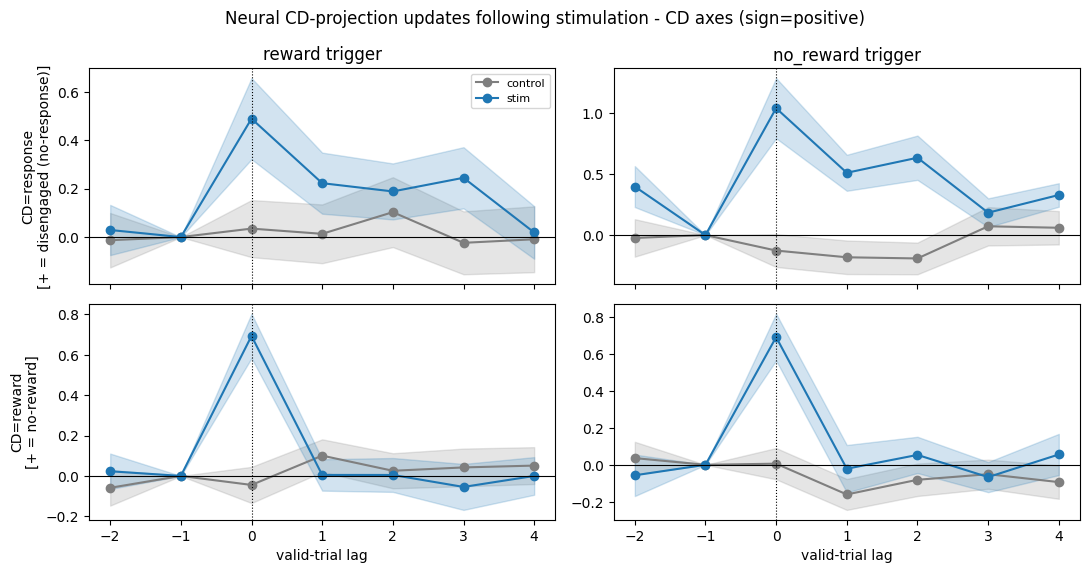

In [40]:
# =============================================================================
# 9. (OPTIONAL) SWEEP CD AXES
# =============================================================================
SWEEP_AXES = ["response", "reward"]

fig, axes = plt.subplots(len(SWEEP_AXES), 2, figsize=(11, 2.9 * len(SWEEP_AXES)),
                         sharex=True, squeeze=False)
for row, axis_name in enumerate(SWEEP_AXES):
    try:
        res_a = build_axis(psth, nwb, unit_ids, axis_name, align=ALIGN_TO,
                           fit_window=FIT_WINDOW, proj_window=PROJ_WINDOW,
                           exclude_trial_ids=opto_trial_ids, cd_sign=CD_SIGN)
        ser = projection_series(res_a, READOUT_WINDOW)
        gg = group_trajectories(ser)
        plab = res_a.axis["label_a"]
    except Exception as e:
        gg, plab = None, "n/a"
        print(f"skip {axis_name}: {e}")
    for col, outcome in enumerate(["reward", "no_reward"]):
        ax = axes[row][col]
        if gg is None:
            ax.text(0.5, 0.5, f"{axis_name}: n/a", transform=ax.transAxes, ha="center")
            ax.axis("off"); continue
        for cond in ["control", "stim"]:
            M = gg[(outcome, cond)]
            mean, sem = _mean_sem(M)
            ax.plot(lags_arr, mean, "-o", color=colors[cond], label=cond)
            ax.fill_between(lags_arr, mean - sem, mean + sem, color=colors[cond], alpha=0.2)
        ax.axvline(0, color="k", ls=":", lw=0.8); ax.axhline(0, color="k", lw=0.8)
        if row == 0:
            ax.set_title(f"{outcome} trigger")
        if col == 0:
            ax.set_ylabel(f"CD={axis_name}\n[+ = {plab}]")
        if row == len(SWEEP_AXES) - 1:
            ax.set_xlabel("valid-trial lag")
axes[0][0].legend(fontsize=8)
fig.suptitle(f"Neural CD-projection updates following stimulation - CD axes (sign={CD_SIGN})")
plt.tight_layout()
fig.savefig(OUTDIR / "trajectory_sweep_axes.png", dpi=150)
plt.show()


## 11. Sweep readout (valuation) windows

The coding direction is fixed (fit once on `FIT_WINDOW`); here we only vary the
**read-out window** - the epoch over which each trial's CD projection is averaged
into the per-trial scalar `y` (the neural analog of the latent value). Each window
answers "the neural state *when*" is updated. Grid: rows = read-out window,
columns = reward / no-reward trigger; stim (blue) vs control (grey), per-lag MWU
stars. A combined CSV (`perlag_readout_sweep_*.csv`) is saved.

Windows must lie inside `PROJ_WINDOW`. Note: a window that overlaps the laser-on
epoch makes lag 0 a direct-stimulation measurement, not a trial-to-trial update.


In [ ]:
# =============================================================================
# 11. SWEEP READOUT (VALUATION) WINDOWS  (CD axis fixed; only the read-out varies)
# =============================================================================
READOUT_SWEEP = [
    ("pre go-cue (-1,0)",  (-1.0, 0.0)),
    ("early (0,0.5)",      (0.0, 0.5)),
    ("outcome (0.5,1.5)",  (0.5, 1.5)),
    ("late (1.5,3.0)",     (1.5, 3.0)),
]

nrow = len(READOUT_SWEEP)
fig, axes3 = plt.subplots(nrow, 2, figsize=(11, 2.8 * nrow), sharex=True, squeeze=False)
rows_out = []
for r, (wlab, win) in enumerate(READOUT_SWEEP):
    ser = projection_series(res, win)         # reuse the already-fit CD (`res`)
    gg = group_trajectories(ser)
    for c, outcome in enumerate(["reward", "no_reward"]):
        ax = axes3[r][c]
        for cond in ["control", "stim"]:
            M = gg[(outcome, cond)]
            mean, sem = _mean_sem(M)
            ax.plot(lags_arr, mean, "-o", color=colors[cond],
                    label=f"{cond} (n={M.shape[0]})")
            ax.fill_between(lags_arr, mean - sem, mean + sem,
                            color=colors[cond], alpha=0.2)
        Ms, Mc = gg[(outcome, "stim")], gg[(outcome, "control")]
        for k, l in enumerate(LAGS):
            a = Ms[:, k]; b = Mc[:, k]
            a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
            p = (mannwhitneyu(a, b, alternative="two-sided")[1]
                 if (len(a) >= 3 and len(b) >= 3) else np.nan)
            if np.isfinite(p) and p < 0.05:
                ytxt = np.nanmax([np.nanmean(Ms[:, k]), np.nanmean(Mc[:, k])])
                ax.text(l, ytxt, "*", ha="center", va="bottom", fontsize=14)
            rows_out.append(dict(
                readout=wlab, window_lo=win[0], window_hi=win[1],
                outcome=outcome, lag=l,
                control_mean=np.mean(b) if len(b) else np.nan, n_control=len(b),
                stim_mean=np.mean(a) if len(a) else np.nan, n_stim=len(a),
                diff=(np.mean(a) - np.mean(b)) if (len(a) and len(b)) else np.nan,
                mannwhitney_p=p))
        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.axhline(0, color="k", lw=0.8)
        if r == 0:
            ax.set_title(f"{outcome} trigger")
        if c == 0:
            ax.set_ylabel(f"{wlab}\nd(CD proj)")
        if r == nrow - 1:
            ax.set_xlabel("valid-trial lag from trigger")
        if r == 0 and c == 0:
            ax.legend(fontsize=7)
fig.suptitle(f"CD-projection update vs read-out window - "
             f"CD={CD_AXIS} (sign={CD_SIGN}) [+ = {pos_label}]")
plt.tight_layout()
fig.savefig(OUTDIR / f"trajectory_readout_sweep_{CD_AXIS}.png", dpi=150)
plt.show()

win_df = pd.DataFrame(rows_out)
win_path = OUTDIR / f"perlag_readout_sweep_{CD_AXIS}.csv"
win_df.to_csv(win_path, index=False)
print(f"saved -> {win_path}")
display(win_df)


## 15. Merged condition sweep (all-in-one)

A single self-contained cell that sweeps **region x stimulation-condition x projection-universe**
and shows every combination in one figure (the core of old sections 10/12/13/14):

- **region** - CD is **re-fit** per unit selection (`UNIT_SELECTIONS`: tagged / ProbeA-C),
- **stimulation condition** - laser trials split by `STIM_GROUP_COLS`; stim = that condition,
  control = shared non-laser triggers; other-condition laser trials skipped; clean window
  free of *any* laser,
- **universe** - responded-only (responded-trial lag) vs incl. no-response (absolute-trial lag).

Rows = region x condition x universe, columns = reward / no-reward; stim (blue) vs control
(grey), per-lag MWU stars. Edit the knob lists at the top to trim the grid. Depends only on
section 3 (loads `psth`/`nwb`/`opto_trial_ids` + the valid-trial arrays) and the config.
Saves `merged_condition_sweep_*.png` / `.csv`.


In [ ]:
# =============================================================================
# 15. MERGED CONDITION SWEEP  (region x stim-condition x projection-universe)
# =============================================================================
from ephys_while_stimulation import summarize_laser_conditions

# ---- knobs ----------------------------------------------------------------
STIM_GROUP_COLS = ("laser_start", "laser_start_offset", "laser_end",
                   "laser_end_offset", "laser_duration")
UNIT_SELECTIONS = [
    ("all-units",  dict(use_tagged=False, probes=None)),
    ("tagged-all", dict(use_tagged=True,  probes=None)),
    ("ProbeA",     dict(use_tagged=False, probes=["ProbeA-1", "ProbeA-2", "ProbeA-3", "ProbeA-4"])),
    ("ProbeB",     dict(use_tagged=False, probes=["ProbeB-1", "ProbeB-2", "ProbeB-3", "ProbeB-4"])),
    ("ProbeC",     dict(use_tagged=False, probes=["ProbeC-1", "ProbeC-2", "ProbeC-3", "ProbeC-4"])),
]
UNIVERSES = [("responded only", False), ("incl. no-response", True)]
# stim-condition indices (row order of stim_summary) to include; None = all
STIM_CONDITIONS = [0, 1]

# ---- enumerate stimulation conditions -------------------------------------
stim_summary = summarize_laser_conditions(nwb, group_cols=STIM_GROUP_COLS)
print(f"{len(stim_summary)} stim condition(s) by {STIM_GROUP_COLS}:")
display(stim_summary.drop(columns=["trial_ids"]))

# ---- helpers (self-contained) ---------------------------------------------
_nz = [l for l in LAGS if l != 0]
_lags = np.array(LAGS)
_col = {"stim": "#1f77b4", "control": "#7f7f7f"}
GKEYS = [("reward", "stim"), ("reward", "control"),
         ("no_reward", "stim"), ("no_reward", "control")]

def _universe(include_no_response):
    ids = (np.arange(responses.size) if include_no_response
           else np.where(responses != 2)[0]).astype(np.int64)
    rew = (rewardedL | rewardedR).astype(int)[ids]
    resp = (responses[ids] != 2).astype(int)
    return ids, rew, resp

def _proj(axis_res, window, ids):
    t = np.asarray(axis_res.time, float); lo, hi = window
    m = (t >= lo) & (t < hi)
    sel = np.where(m)[0] if m.any() else np.array([int(np.argmin(np.abs(t - 0.5 * (lo + hi))))])
    out = np.full(len(ids), np.nan)
    for i, tid in enumerate(ids):
        tr = axis_res.trace_by_id.get(int(tid))
        if tr is not None:
            out[i] = float(np.nanmean(np.asarray(tr, float)[sel]))
    return out

def _groups(ids_u, rew_u, resp_u, y_u, cond_ids):
    n = len(ids_u)
    any_laser = (laser_on[ids_u] == 1)
    cond_stim = np.isin(ids_u, np.asarray(cond_ids, np.int64))
    def clean(i):
        for l in _nz:
            j = i + l
            if 0 <= j < n and any_laser[j]:
                return False
        return True
    g = {k: [] for k in GKEYS}
    for i in range(n):
        if resp_u[i] != 1:
            continue
        if cond_stim[i]:
            cond = "stim"
        elif not any_laser[i]:
            cond = "control"
        else:
            continue
        b = i + BASELINE_LAG
        if b < 0 or b >= n or np.isnan(y_u[b]):
            continue
        if REQUIRE_CLEAN_WINDOW and not clean(i):
            continue
        traj = np.full(len(LAGS), np.nan)
        for k, l in enumerate(LAGS):
            j = i + l
            if 0 <= j < n:
                traj[k] = y_u[j] - y_u[b]
        g[("reward" if rew_u[i] == 1 else "no_reward", cond)].append(traj)
    return {k: (np.vstack(v) if v else np.empty((0, len(LAGS)))) for k, v in g.items()}

def _ms(M):
    if M.shape[0] == 0:
        return np.full(M.shape[1], np.nan), np.full(M.shape[1], np.nan)
    nn = np.sum(~np.isnan(M), axis=0)
    mean = np.nanmean(M, axis=0)
    sd = np.nanstd(M, axis=0, ddof=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        sem = sd / np.sqrt(np.maximum(nn, 1))
    return mean, sem

# ---- build every panel ----------------------------------------------------
uni_ids = {ul: _universe(inc) for ul, inc in UNIVERSES}
panels, pos_label = [], None
for rlab, kw in UNIT_SELECTIONS:
    try:
        uids = select_units(nwb, psth, metrics_csv_path=metrics_csv_path,
                            target_cond=target_cond, pulse_index=SELECT_PULSE_INDEX, **kw)
        if len(uids) < 3:
            print(f"skip region {rlab}: only {len(uids)} units"); continue
        res_r = build_axis(psth, nwb, uids, CD_AXIS, align=ALIGN_TO, fit_window=FIT_WINDOW,
                           proj_window=PROJ_WINDOW, exclude_trial_ids=opto_trial_ids,
                           cd_sign=CD_SIGN)
    except Exception as e:
        print(f"skip region {rlab}: {e}"); continue
    pos_label = res_r.axis["label_a"]
    proj_u = {ul: _proj(res_r, READOUT_WINDOW, uni_ids[ul][0]) for ul, _ in UNIVERSES}
    for ci, srow in stim_summary.iterrows():
        if STIM_CONDITIONS is not None and ci not in STIM_CONDITIONS:
            continue
        cond_ids = np.asarray(srow["trial_ids"], np.int64)
        for ul, inc in UNIVERSES:
            ids_u, rew_u, resp_u = uni_ids[ul]
            panels.append((rlab, len(uids), ci, ul,
                           _groups(ids_u, rew_u, resp_u, proj_u[ul], cond_ids)))

# ---- one figure -----------------------------------------------------------
if not panels:
    print("No usable region/condition combination.")
else:
    nrow = len(panels)
    fig, axes = plt.subplots(nrow, 2, figsize=(11, 2.3 * nrow), sharex=True, squeeze=False)
    rows_out = []
    for r, (rlab, nu, ci, ul, g) in enumerate(panels):
        for c, outcome in enumerate(["reward", "no_reward"]):
            ax = axes[r][c]
            for cond in ["control", "stim"]:
                M = g[(outcome, cond)]; mean, sem = _ms(M)
                ax.plot(_lags, mean, "-o", color=_col[cond], label=f"{cond} (n={M.shape[0]})")
                ax.fill_between(_lags, mean - sem, mean + sem, color=_col[cond], alpha=0.2)
            Ms, Mc = g[(outcome, "stim")], g[(outcome, "control")]
            for k, l in enumerate(LAGS):
                a = Ms[:, k]; b = Mc[:, k]
                a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
                p = (mannwhitneyu(a, b, alternative="two-sided")[1]
                     if (len(a) >= 3 and len(b) >= 3) else np.nan)
                if np.isfinite(p) and p < 0.05:
                    ax.text(l, np.nanmax([np.nanmean(Ms[:, k]), np.nanmean(Mc[:, k])]),
                            "*", ha="center", va="bottom", fontsize=12)
                rows_out.append(dict(
                    region=rlab, n_units=nu, condition=ci, universe=ul, outcome=outcome, lag=l,
                    control_mean=np.mean(b) if len(b) else np.nan, n_control=len(b),
                    stim_mean=np.mean(a) if len(a) else np.nan, n_stim=len(a),
                    diff=(np.mean(a) - np.mean(b)) if (len(a) and len(b)) else np.nan,
                    mannwhitney_p=p))
            ax.axvline(0, color="k", ls=":", lw=0.8); ax.axhline(0, color="k", lw=0.8)
            if r == 0:
                ax.set_title(f"{outcome} trigger")
            if c == 0:
                ax.set_ylabel(f"{rlab} (u={nu})\ncond {ci} / {ul}", fontsize=7)
            if r == nrow - 1:
                ax.set_xlabel("lag from trigger")
            ax.legend(fontsize=6)
    fig.suptitle(f"Merged sweep: region x condition x universe - "
                 f"CD={CD_AXIS} (sign={CD_SIGN}) [+ = {pos_label}]")
    plt.tight_layout()
    fig.savefig(OUTDIR / f"merged_condition_sweep_{CD_AXIS}.png", dpi=150)
    plt.show()

    merged_df = pd.DataFrame(rows_out)
    merged_path = OUTDIR / f"merged_condition_sweep_{CD_AXIS}.csv"
    merged_df.to_csv(merged_path, index=False)
    print(f"saved -> {merged_path}")
    display(merged_df)
